# HR Employee Attrition Analysis
**Dataset:** IBM HR Analytics Employee Attrition Dataset (Kaggle)  
**Goal:** Identify key drivers of employee turnover and predict attrition risk  
**Tools:** Python (pandas, seaborn, scikit-learn), Power BI

# **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# **2. Load Data**

In [4]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print('Dataset Shape:', df.shape)


Dataset Shape: (1470, 35)


In [6]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())
print(df['Attrition'].value_counts())

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

# **3. Exploratory Data Analysis (EDA)**

In [7]:
# Attrition Distribution
attrition_count = df['Attrition'].value_counts()
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100

print('Attrition Count:')
print(attrition_count)
print('\nAttrition Rate:')
print(attrition_rate.round(1))

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate:
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


In [10]:
# Encode target variable
le = LabelEncoder()
df['Attrition_enc'] = le.fit_transform(df['Attrition'])  # No=0, Yes=1

# Encode OverTime
df['OverTime_enc'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# Select features
features = ['Age', 'MonthlyIncome', 'YearsAtCompany',
            'JobSatisfaction', 'OverTime_enc', 'WorkLifeBalance',
            'DistanceFromHome', 'NumCompaniesWorked']

X = df[features]
y = df['Attrition_enc']

print('Features shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Features shape: (1470, 8)
Target distribution:
Attrition_enc
0    1233
1     237
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 1176 samples
Test set: 294 samples


In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.1f}%')
print('='*50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

Accuracy: 84.7%

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.87      0.97      0.92       255
   Attrition       0.20      0.05      0.08        39

    accuracy                           0.85       294
   macro avg       0.53      0.51      0.50       294
weighted avg       0.78      0.85      0.81       294



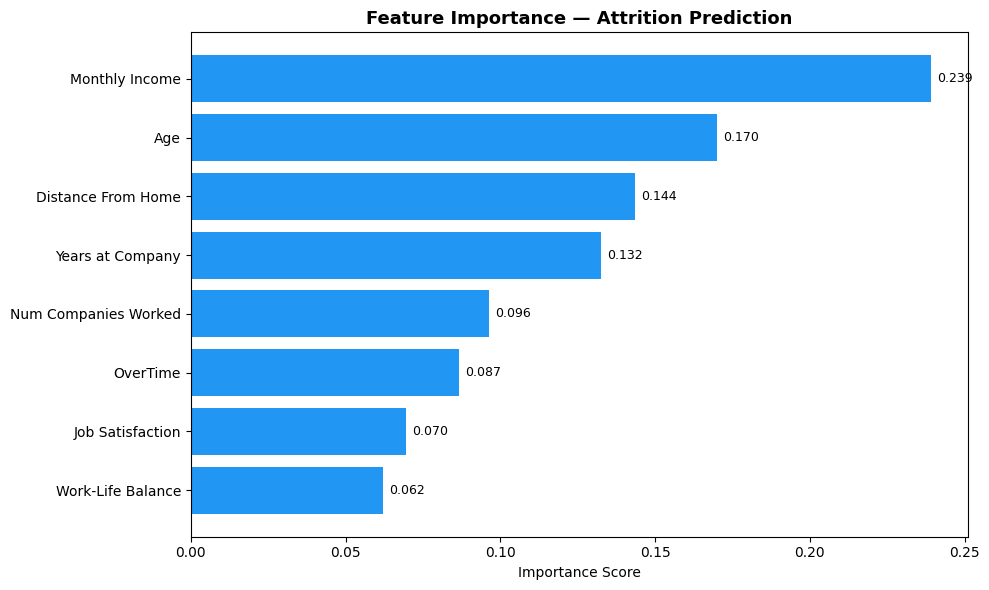

Saved: feature_importance.png


In [14]:
# Feature importance visualization
feature_names = ['Age', 'Monthly Income', 'Years at Company',
                 'Job Satisfaction', 'OverTime', 'Work-Life Balance',
                 'Distance From Home', 'Num Companies Worked']

importances = pd.Series(model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importances.index, importances.values, color='#2196F3')
plt.title('Feature Importance — Attrition Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')

# Add value labels
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## 8. Key Insights

| Insight | Finding |
|---|---|
| Overall Attrition Rate | 16.1% (237 out of 1,470 employees) |
| Highest Risk Department | Sales (highest attrition rate %) |
| Top Attrition Driver | Monthly Income |
| OverTime Impact | Employees working overtime leave significantly more |
| Tenure Risk | First year employees have the highest attrition |

### Model Performance
- **Accuracy:** 84.7%
- **Note:** Class imbalance detected (1,233 No vs 237 Yes). Model performs well on majority class but has lower recall on attrition cases.